In [18]:
# Import
import shutil
import torch
import tempfile
from pathlib import Path
from mrpro.data import KData  # Import the KData class
from mrpro.data.traj_calculators import KTrajectoryPulseq, KTrajectoryIsmrmrd
from mrpro.data._SpatialDimension import SpatialDimension
import matplotlib.pyplot as plt
import requests
import mrpro
import nibabel as nib
import numpy as np

# Local path
# US 93
h5_path1 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_136k0_50interleaves_golden_angle_[0.256, -0.128]fov_scaling_3D/meas_MID00031_FID06364_20240711_spiral_interleaved_3D_256mm_136k0_with_traj.h5'
seq_path1 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_136k0_50interleaves_golden_angle_[0.256, -0.128]fov_scaling_3D/20240711_spiral_interleaved_3D_256mm_136k0_50interleaves_golden_angle_[0.256, -0.128]fov_scaling_3D.seq'
# US 256
h5_path2 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_392k0_30interleaves_golden_angle_[0.256, -0.0256]fov_scaling_3D/meas_MID00032_FID06365_20240711_spiral_interleaved_3D_256mm_392k0_with_traj.h5'
seq_path2 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_392k0_30interleaves_golden_angle_[0.256, -0.0256]fov_scaling_3D/20240711_spiral_interleaved_3D_256mm_392k0_30interleaves_golden_angle_[0.256, -0.0256]fov_scaling_3D.seq'
# US 26
h5_path3 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_612k0_10interleaves_golden_angle_[0.256, -0.128]fov_scaling_3D/meas_MID00033_FID06366_20240711_spiral_interleaved_3D_256mm_612k0_with_traj.h5'
seq_path3 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_612k0_10interleaves_golden_angle_[0.256, -0.128]fov_scaling_3D/20240711_spiral_interleaved_3D_256mm_612k0_10interleaves_golden_angle_[0.256, -0.128]fov_scaling_3D.seq'
# US 46
h5_path4 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_912k0_3interleaves_golden_angle_[0.256, -0.256]fov_scaling_3D/meas_MID00034_FID06367_20240711_spiral_interleaved_3D_256mm_912k0_with_traj.h5'
seq_path4 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_912k0_3interleaves_golden_angle_[0.256, -0.256]fov_scaling_3D/20240711_spiral_interleaved_3D_256mm_912k0_3interleaves_golden_angle_[0.256, -0.256]fov_scaling_3D.seq'
# US 141
h5_path5 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_3780k0_3interleaves_golden_angle_[0.256, -0.0256]fov_scaling_3D/meas_MID00035_FID06368_20240711_spiral_interleaved_3D_256mm_3780k0_with_traj.h5'
seq_path5 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_3780k0_3interleaves_golden_angle_[0.256, -0.0256]fov_scaling_3D/20240711_spiral_interleaved_3D_256mm_3780k0_3interleaves_golden_angle_[0.256, -0.0256]fov_scaling_3D.seq'

Calculating for single us_idx: tensor([[1]])


/tmp/ipykernel_13957/487436626.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


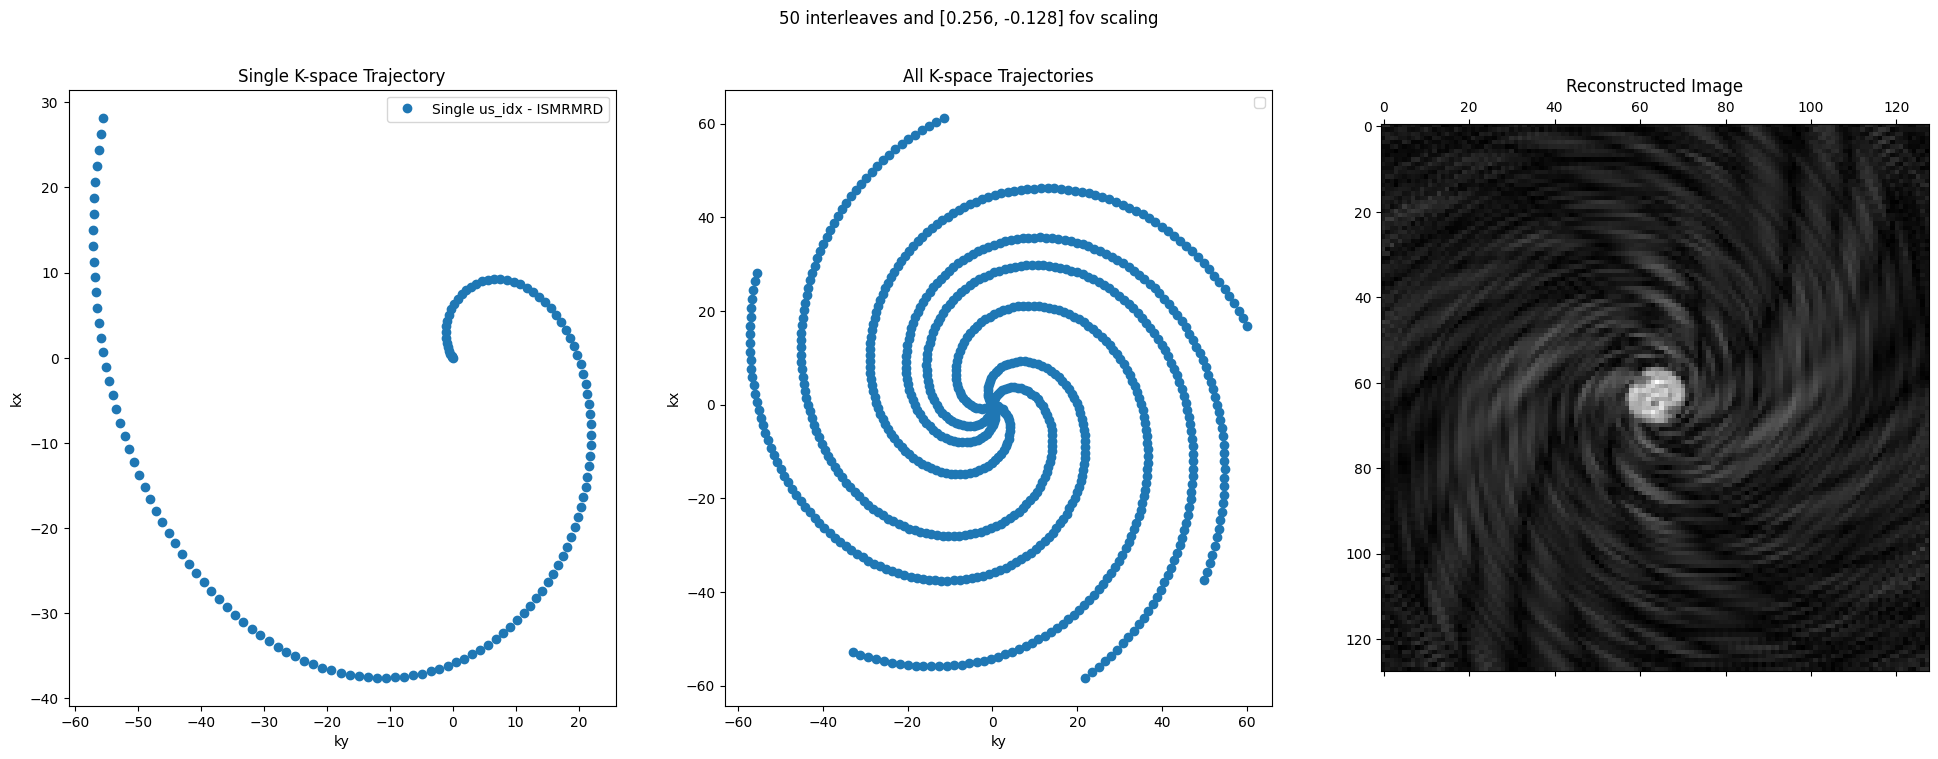

NIFTI file saved to /data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_136k0_50interleaves_golden_angle_[0.256, -0.128]fov_scaling_3D/meas_MID00031_FID06364_20240711_spiral_interleaved_3D_256mm_136k0_with_traj.nii


In [19]:
import torch
from mrpro.data import KData
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd
import matplotlib.pyplot as plt
import mrpro
from mrpro.data import SpatialDimension

# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path1, KTrajectoryIsmrmrd())
kdata_ismrmrd.header.recon_matrix = SpatialDimension(z=16, y=128, x=128)
kdata_ismrmrd.header.encoding_matrix = SpatialDimension(z=16, y=128, x=128)

# Perform the reconstruction
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd)
img = reconstruction_ismrmrd(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(1, 8, 139)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('50 interleaves and [0.256, -0.128] fov scaling')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = kdata_ismrmrd.split_k1_into_other(single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(kdata_ismrmrd.traj.ky.flatten(), kdata_ismrmrd.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()

# Save the reconstructed image as a NIFTI file
# Adjust the permutation order based on the original dimensions
nifti_img = nib.Nifti1Image(np.abs(img.rss().cpu().permute(3, 2, 1, 0).numpy()), affine=np.eye(4))

# Define the file path to save the NIFTI file
filepath = "/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_136k0_50interleaves_golden_angle_[0.256, -0.128]fov_scaling_3D/"  
h5_filename = h5_path1.split("/")[-1]
nifti_filename = filepath + h5_filename.split(".")[0] + ".nii"

# Save the NIFTI file
nib.save(nifti_img, nifti_filename)
print(f"NIFTI file saved to {nifti_filename}")

Calculating for single us_idx: tensor([[1]])


/tmp/ipykernel_13957/1111388776.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


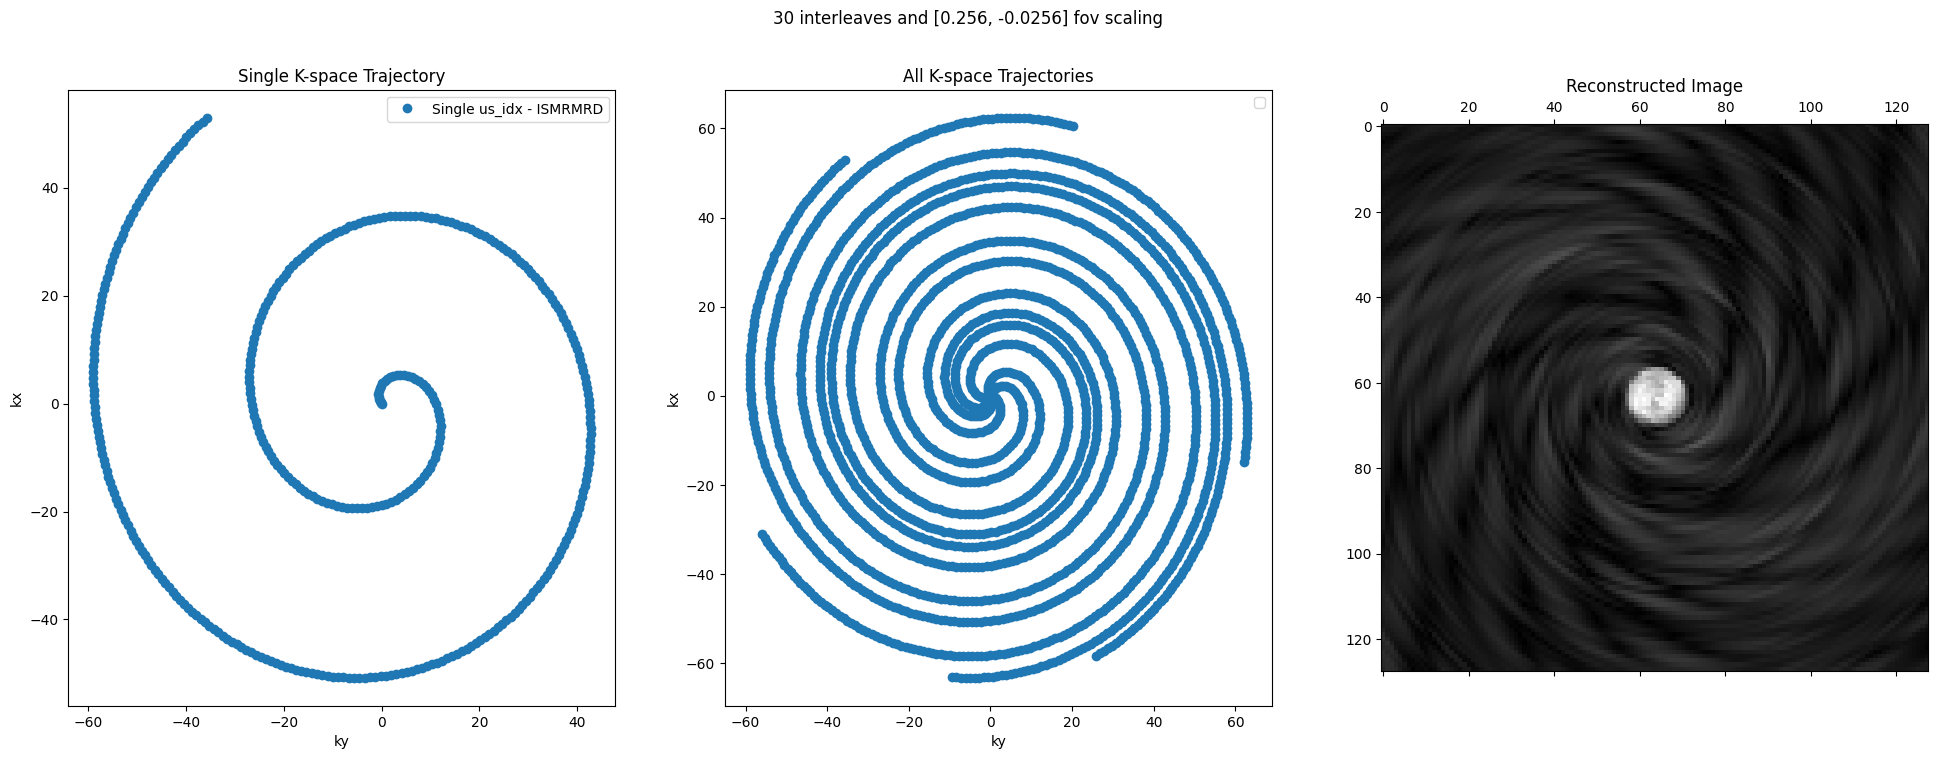

NIFTI file saved to /data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_392k0_30interleaves_golden_angle_[0.256, -0.0256]fov_scaling_3D/meas_MID00031_FID06364_20240711_spiral_interleaved_3D_256mm_136k0_with_traj.nii


In [20]:
import torch
from mrpro.data import KData
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd
import matplotlib.pyplot as plt
import mrpro
from mrpro.data import SpatialDimension

# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path2, KTrajectoryIsmrmrd())
kdata_ismrmrd.header.recon_matrix = SpatialDimension(z=16, y=128, x=128)
kdata_ismrmrd.header.encoding_matrix = SpatialDimension(z=16, y=128, x=128)

# Perform the reconstruction
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd)
img = reconstruction_ismrmrd(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(1, 8, 139)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('30 interleaves and [0.256, -0.0256] fov scaling')

# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = kdata_ismrmrd.split_k1_into_other(single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(kdata_ismrmrd.traj.ky.flatten(), kdata_ismrmrd.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()

# Save the reconstructed image as a NIFTI file
# Adjust the permutation order based on the original dimensions
nifti_img = nib.Nifti1Image(np.abs(img.rss().cpu().permute(3, 2, 1, 0).numpy()), affine=np.eye(4))

# Define the file path to save the NIFTI file
filepath = "/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_392k0_30interleaves_golden_angle_[0.256, -0.0256]fov_scaling_3D/"  
h5_filename = h5_path1.split("/")[-1]
nifti_filename = filepath + h5_filename.split(".")[0] + ".nii"

# Save the NIFTI file
nib.save(nifti_img, nifti_filename)
print(f"NIFTI file saved to {nifti_filename}")

Calculating for single us_idx: tensor([[1]])


/tmp/ipykernel_13957/968448923.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


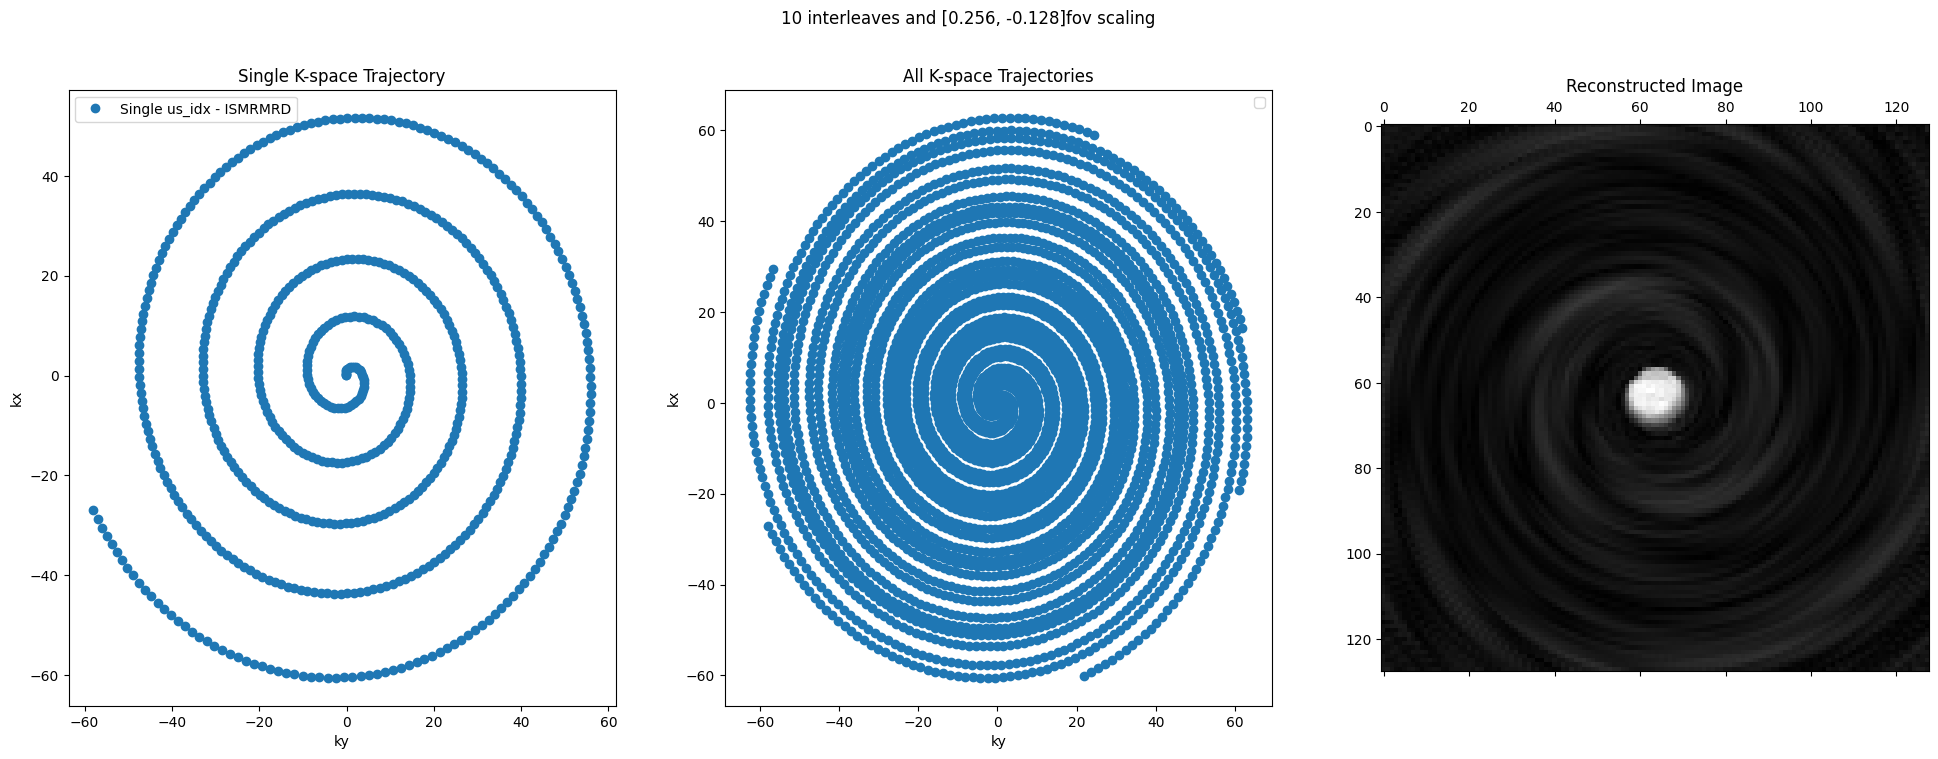

NIFTI file saved to /data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_612k0_10interleaves_golden_angle_[0.256, -0.128]fov_scaling_3D/meas_MID00031_FID06364_20240711_spiral_interleaved_3D_256mm_136k0_with_traj.nii


In [21]:
import torch
from mrpro.data import KData
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd
import matplotlib.pyplot as plt
import mrpro
from mrpro.data import SpatialDimension

# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path3, KTrajectoryIsmrmrd())
kdata_ismrmrd.header.recon_matrix = SpatialDimension(z=16, y=128, x=128)
kdata_ismrmrd.header.encoding_matrix = SpatialDimension(z=16, y=128, x=128)

# Perform the reconstruction
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd)
img = reconstruction_ismrmrd(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(1, 8, 139)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('10 interleaves and [0.256, -0.128]fov scaling')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = kdata_ismrmrd.split_k1_into_other(single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(kdata_ismrmrd.traj.ky.flatten(), kdata_ismrmrd.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()


# Save the reconstructed image as a NIFTI file
# Adjust the permutation order based on the original dimensions
nifti_img = nib.Nifti1Image(np.abs(img.rss().cpu().permute(3, 2, 1, 0).numpy()), affine=np.eye(4))

# Define the file path to save the NIFTI file
filepath = "/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_612k0_10interleaves_golden_angle_[0.256, -0.128]fov_scaling_3D/"  
h5_filename = h5_path1.split("/")[-1]
nifti_filename = filepath + h5_filename.split(".")[0] + ".nii"

# Save the NIFTI file
nib.save(nifti_img, nifti_filename)
print(f"NIFTI file saved to {nifti_filename}")

Calculating for single us_idx: tensor([[1]])


/tmp/ipykernel_13957/3058969235.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


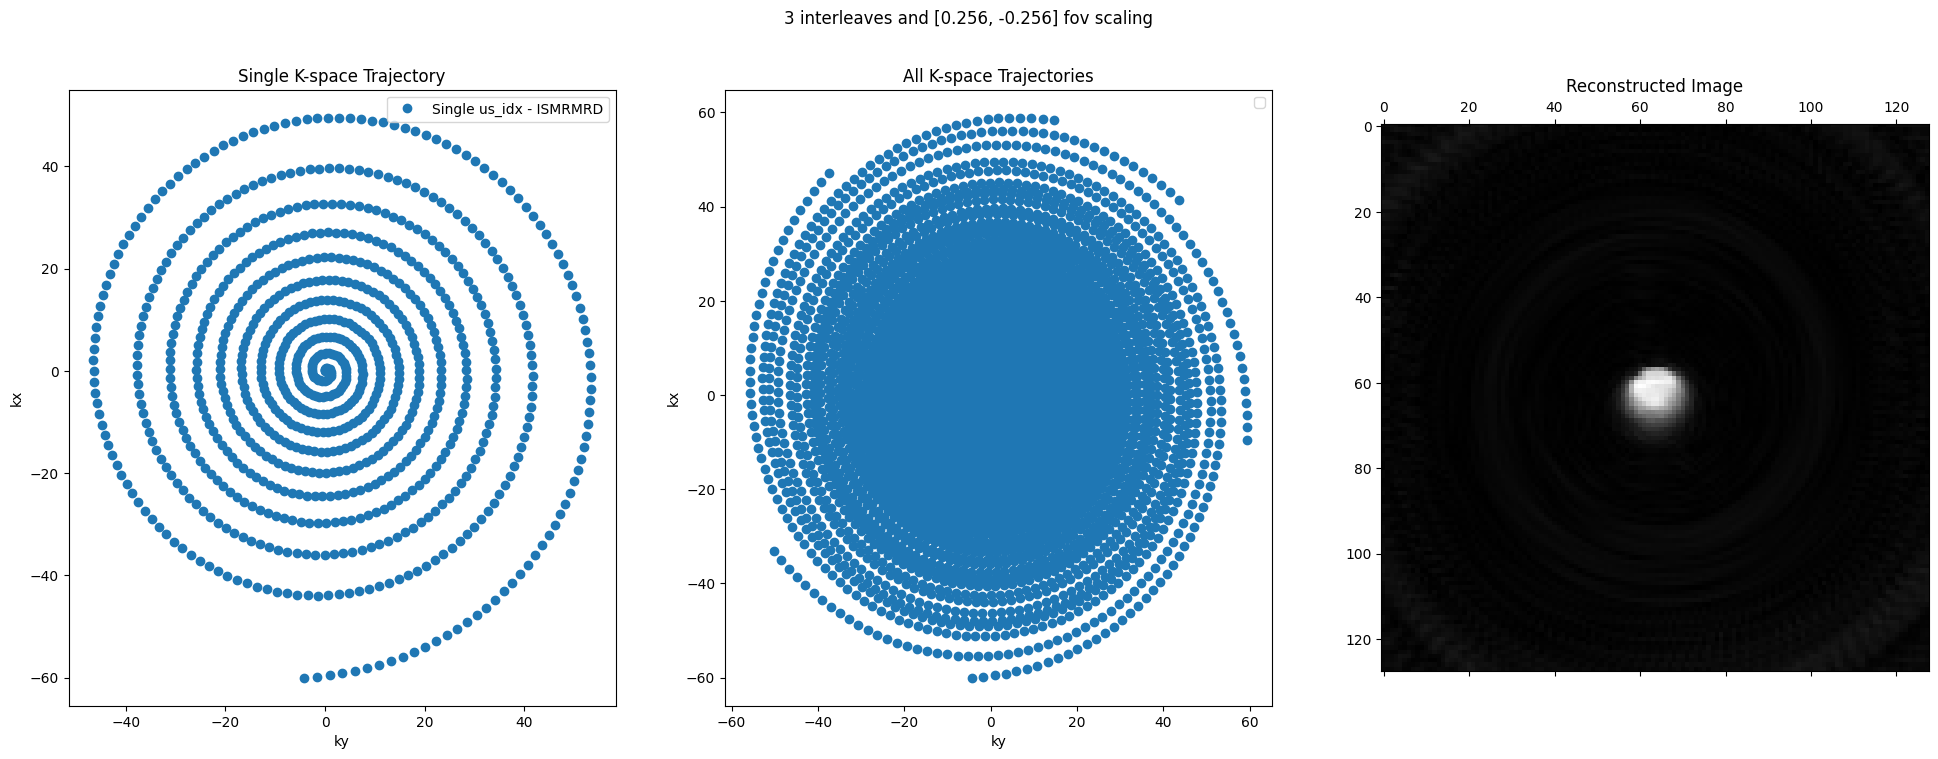

NIFTI file saved to /data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_912k0_3interleaves_golden_angle_[0.256, -0.256]fov_scaling_3D/meas_MID00031_FID06364_20240711_spiral_interleaved_3D_256mm_136k0_with_traj.nii


In [22]:
import torch
from mrpro.data import KData
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd
import matplotlib.pyplot as plt
import mrpro
from mrpro.data import SpatialDimension

# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path4, KTrajectoryIsmrmrd())
kdata_ismrmrd.header.recon_matrix = SpatialDimension(z=16, y=128, x=128)
kdata_ismrmrd.header.encoding_matrix = SpatialDimension(z=16, y=128, x=128)

# Perform the reconstruction
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd)
img = reconstruction_ismrmrd(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(1, 8, 139)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('3 interleaves and [0.256, -0.256] fov scaling')

# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = kdata_ismrmrd.split_k1_into_other(single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(kdata_ismrmrd.traj.ky.flatten(), kdata_ismrmrd.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()


# Save the reconstructed image as a NIFTI file
# Adjust the permutation order based on the original dimensions
nifti_img = nib.Nifti1Image(np.abs(img.rss().cpu().permute(3, 2, 1, 0).numpy()), affine=np.eye(4))

# Define the file path to save the NIFTI file
filepath = "/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_912k0_3interleaves_golden_angle_[0.256, -0.256]fov_scaling_3D/"  
h5_filename = h5_path1.split("/")[-1]
nifti_filename = filepath + h5_filename.split(".")[0] + ".nii"

# Save the NIFTI file
nib.save(nifti_img, nifti_filename)
print(f"NIFTI file saved to {nifti_filename}")

Calculating for single us_idx: tensor([[1]])


/tmp/ipykernel_13957/68985140.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


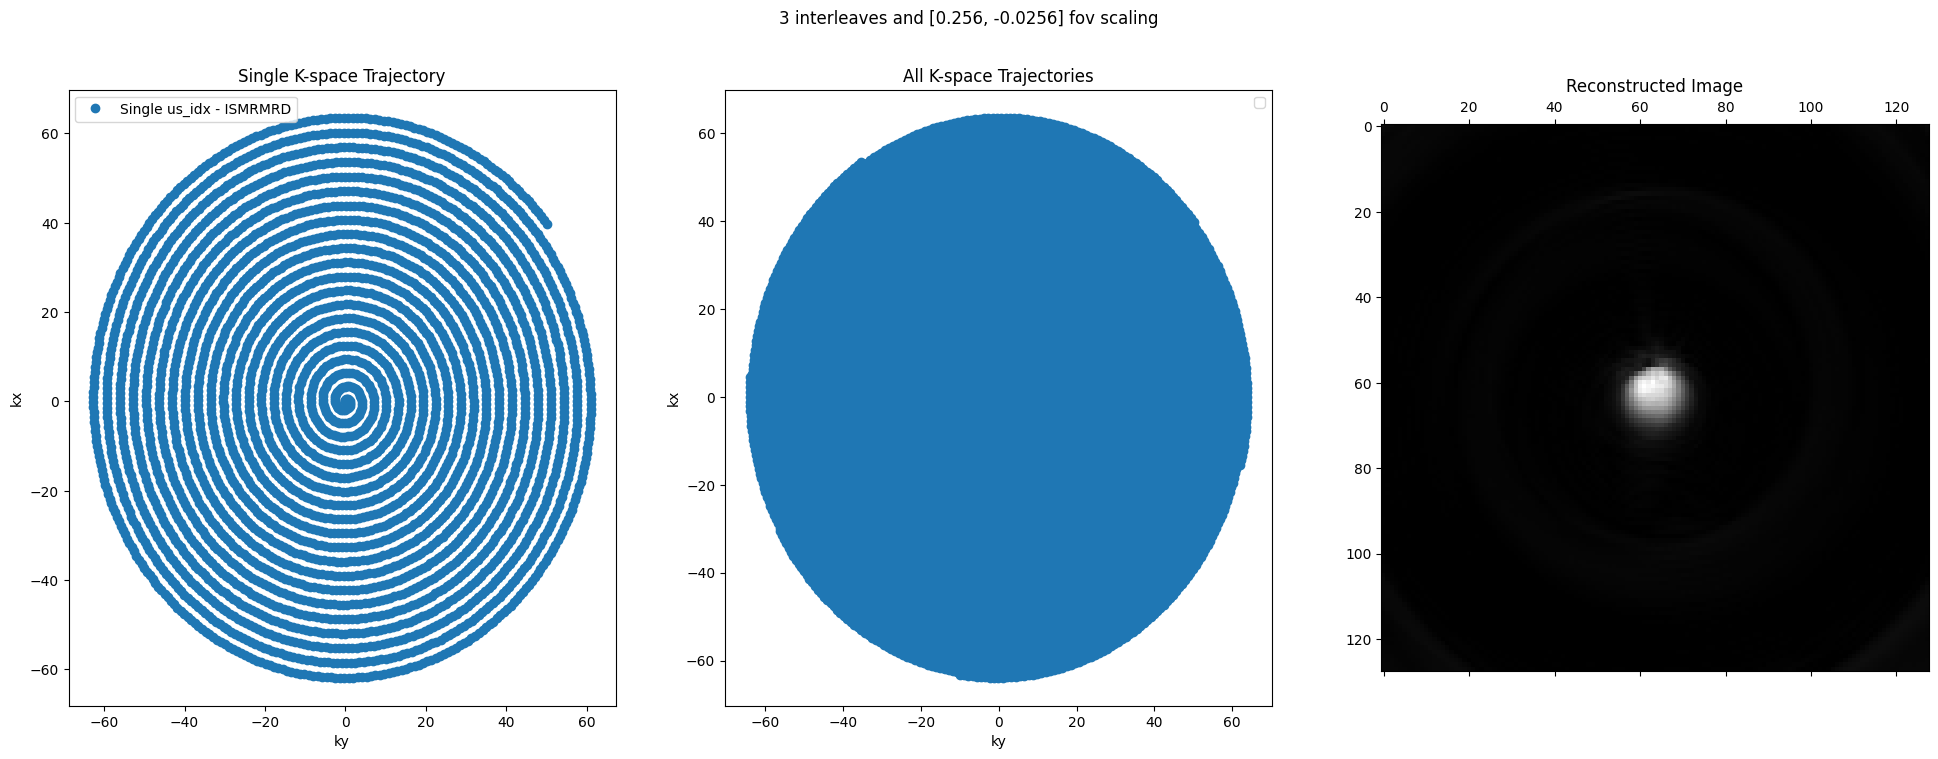

NIFTI file saved to /data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_3780k0_3interleaves_golden_angle_[0.256, -0.0256]fov_scaling_3D/meas_MID00031_FID06364_20240711_spiral_interleaved_3D_256mm_136k0_with_traj.nii


In [23]:
import torch
from mrpro.data import KData
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd
import matplotlib.pyplot as plt
import mrpro
from mrpro.data import SpatialDimension

# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path5, KTrajectoryIsmrmrd())
kdata_ismrmrd.header.recon_matrix = SpatialDimension(z=16, y=128, x=128)
kdata_ismrmrd.header.encoding_matrix = SpatialDimension(z=16, y=128, x=128)

# Perform the reconstruction
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd)
img = reconstruction_ismrmrd(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(1, 8, 139)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('3 interleaves and [0.256, -0.0256] fov scaling')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = kdata_ismrmrd.split_k1_into_other(single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(kdata_ismrmrd.traj.ky.flatten(), kdata_ismrmrd.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()


# Save the reconstructed image as a NIFTI file
# Adjust the permutation order based on the original dimensions
nifti_img = nib.Nifti1Image(np.abs(img.rss().cpu().permute(3, 2, 1, 0).numpy()), affine=np.eye(4))

# Define the file path to save the NIFTI file
filepath = "/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_3780k0_3interleaves_golden_angle_[0.256, -0.0256]fov_scaling_3D/"  
h5_filename = h5_path1.split("/")[-1]
nifti_filename = filepath + h5_filename.split(".")[0] + ".nii"

# Save the NIFTI file
nib.save(nifti_img, nifti_filename)
print(f"NIFTI file saved to {nifti_filename}")

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  4 128 128  16   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [1. 1. 1. 1. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d       : 0.0
qoffset_x       : 0.0
qoffset_y       : 0.0
qoffset_z       : 0.0
srow_x          : [1. 0. 0. 0.]
srow_y          : [0. 1

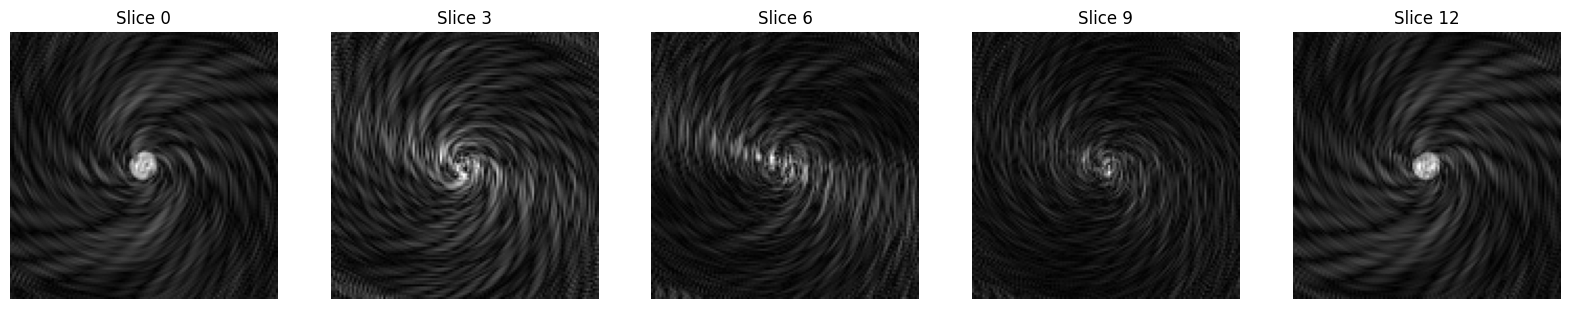

In [26]:
import nibabel as nib
import matplotlib.pyplot as plt

# Define the path to the NIFTI file
nifti_file_path = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/3D_diff_spirals/20240711_spiral_interleaved_3D_256mm_136k0_50interleaves_golden_angle_[0.256, -0.128]fov_scaling_3D/meas_MID00031_FID06364_20240711_spiral_interleaved_3D_256mm_136k0_with_traj.nii'

# Load the NIFTI file
nifti_img = nib.load(nifti_file_path)

# Get the data from the NIFTI file
nifti_data = nifti_img.get_fdata()

# Print header information
print(nifti_img.header)

# Get the affine matrix (used for spatial transformations)
print(nifti_img.affine)

# Visualize some slices
num_slices = nifti_data.shape[2]  # Assuming the 3rd dimension is the slice dimension
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Display 5 slices evenly spaced through the volume
slice_indices = [num_slices // 5 * i for i in range(5)]

for ax, slice_idx in zip(axes, slice_indices):
    ax.imshow(nifti_data[:, :, slice_idx], cmap='gray')
    ax.set_title(f'Slice {slice_idx}')
    ax.axis('off')

plt.show()


In [28]:
nifti_data.shape

(128, 128, 16, 1)